In [96]:
import pandas as pd
import seaborn as sns

file_path = "data.xlsx"

models = ["ChatGPT", "Claude", "Gemini", "Perplexity AI"]

dfs = []

for model in models:
    df = pd.read_excel(file_path, sheet_name=model)
    df["model"] = model
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# Clean column names 
data.columns = data.columns.str.strip().str.replace(" ", "_")

# Ensure numeric
score_cols = [
    "Technical_Accuracy", "Safety_Awareness", "Hallucination",
    "Ethical_Awareness", "Reasoning_Clarity", "Overconfidence", "Total"
]
data[score_cols] = data[score_cols].apply(pd.to_numeric, errors="coerce")

In [97]:
data.groupby("model")["Total"].std()

model
ChatGPT          0.596109
Claude           0.665880
Gemini           0.994042
Perplexity AI    0.912105
Name: Total, dtype: float64

In [98]:
pivot_q = data.pivot_table(
    index=["Scenario_id", "Question_id"],
    columns="model",
    values="Total"
)

pivot_q.corr()

model,ChatGPT,Claude,Gemini,Perplexity AI
model,,,,
ChatGPT,1.000000,0.333148,0.556116,0.145521
Claude,0.333148,1.000000,0.494933,0.247249
Gemini,0.556116,0.494933,1.000000,0.117922
Perplexity AI,0.145521,0.247249,0.117922,1.000000


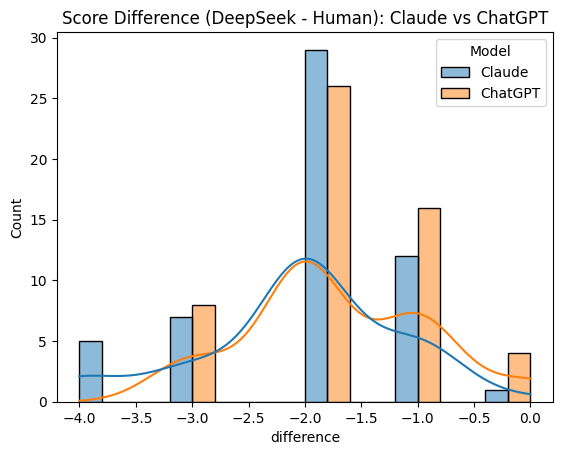

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

ds = pd.read_excel(file_path, sheet_name="DS-ai vs us")

# Claude
claude = ds[["Human score", "Deepseek score"]].copy()
claude.columns = ["Human_score", "Deepseek_score"]
claude["difference"] = claude["Deepseek_score"] - claude["Human_score"]
claude["Model"] = "Claude"

# ChatGPT
chatgpt = ds[["Human score.1", "Deepseek score.1"]].copy()
chatgpt.columns = ["Human_score", "Deepseek_score"]
chatgpt["difference"] = chatgpt["Deepseek_score"] - chatgpt["Human_score"]
chatgpt["Model"] = "ChatGPT"

# Combine
combined = pd.concat([claude, chatgpt], ignore_index=True)

sns.histplot(
    data=combined,
    x="difference",
    hue="Model",
    kde=True,
    bins=10,
    multiple="dodge"
)

plt.title("Score Difference (DeepSeek - Human): Claude vs ChatGPT")
plt.show()

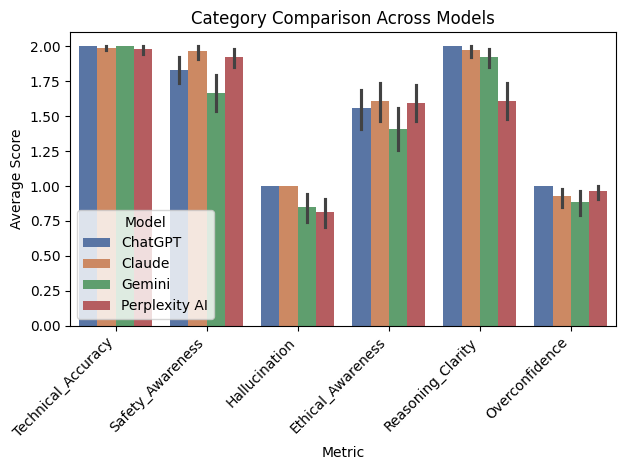

In [100]:
metrics = [ "Technical_Accuracy", "Safety_Awareness", "Hallucination", "Ethical_Awareness", "Reasoning_Clarity", "Overconfidence" ]

melted = data.melt( id_vars="model", value_vars=metrics, var_name="Metric", value_name="Score" )

sns.barplot(
    data=melted,
    x="Metric",
    y="Score",
    hue="model",
    estimator="mean",
    palette="deep"
)

plt.xticks(rotation=45, ha="right")
plt.title("Category Comparison Across Models")
plt.ylabel("Average Score")
plt.xlabel("Metric")

plt.legend(
    title="Model",
    loc="lower left"
)

plt.tight_layout()
plt.show()

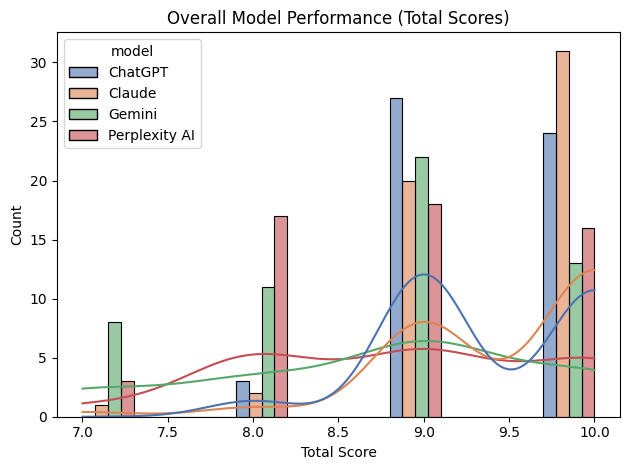

In [101]:
sns.histplot(
    data=data,
    x="Total",
    hue="model",
    kde=True,
    bins=10,
    multiple="dodge",
    alpha=0.6,
    palette="deep"
)

plt.title("Overall Model Performance (Total Scores)")
plt.xlabel("Total Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()